# Sieci neuronowe i Deep Learning
# Temat 3: Wielowarstwowy perceptron i algorytm wstecznej propagacji błędu

numpy: 1.21.2
matplotlib: 3.4.3
sklearn: 1.0

# Klasyfikacja odręcznie pisanych cyfr

## Zbiór danych MNIST

Zbiór danych **MNIST** (Mixed National Institute of Standards and Technology) jest dostępny pod ardesem http://yann.lecun.com/exdb/mnist/ i składa się z czterech części:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples),
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels),
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples),
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels).

Zbiór treningowy: dane od 250 różnych osób (50% od uczniów szkół średnich i 50% od pracowników Urzędu Spisu Ludności).

W zbiorze testowym zachowana jest taka sama proporcja w źródłach danych.

In [ ]:
# Funckja fetch_openml (z scikit-learn) pobiera zbiór danych MNIST
# z OpenML (https://www.openml.org/d/554) jako obiekty typu DataFrame i Series z pandas
# (dlatego używamy atrybutu .values, aby otrzymać tablicę NumPy).

from sklearn.datasets import fetch_openml


X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


70 000 obrazków (po 784 pikseli każdy = 28 x 28).

70 000 etykiet (cyfry od 0 do 9, które zostały zapisane odręcznie i są przedstawione na zdjęciach).

Dla każdego piksela podana jest wartość jasności na skali szarości - wyrażanej wartościami w zakresie od 0 do 255.

In [ ]:
# Normalizacja cech do przedziału [-1,1]
# (pod optymalizację metodą gradientową):
X = ((X / 255.) - .5) * 2

Przykładowe zdjęcia - pierwsza cyfra z każdej klasy (funkcja imshow() z Matplotlib daje możliwość odtworzenia obrazu na podstawie parametryzacji jak u nas):

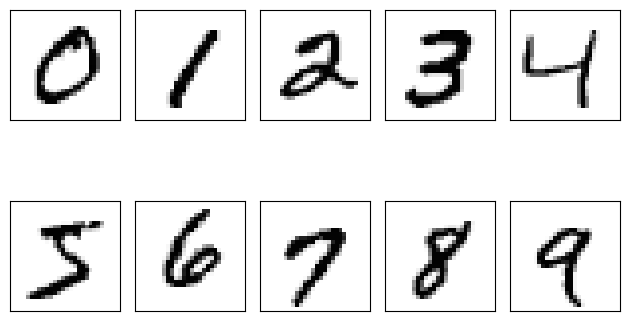

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()

plt.show()

25 wersji cyfry ,,7":

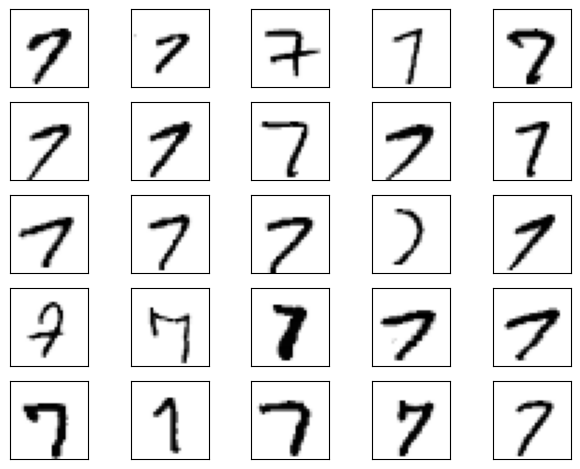

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()

plt.show()

<br>
<br>

Podzielmy ten zbiór danych na zbiór uczący, zbiór walidacyjny oraz zbiór testowy (55 000 + 5 000 + 10 000):

In [ ]:
'''
def liczba_na_wektor(liczba):
    wektor = [0] * 10
    wektor[liczba] = liczba
    return wektor

# Konwersja ciągów znaków na liczby całkowite
y = [int(elem) for elem in y]

# Wykorzystanie pętli for do przekształcenia liczb na wektory
for i in range(len(y)):
    y[i] = liczba_na_wektor(y[i])
'''


'\ndef liczba_na_wektor(liczba):\n    wektor = [0] * 10\n    wektor[liczba] = liczba\n    return wektor\n\n# Konwersja ciągów znaków na liczby całkowite\ny = [int(elem) for elem in y]\n\n# Wykorzystanie pętli for do przekształcenia liczb na wektory\nfor i in range(len(y)):\n    y[i] = liczba_na_wektor(y[i])\n'

In [ ]:
print(y)

[5 0 4 ... 4 5 6]


In [ ]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)


# optional to free up some memory by deleting non-used arrays:
del X_temp, y_temp, X, y

## Implementacja wielowarstwowego perceptronu
z jedną warstwą ukrytą, sigmoidalną funkcją aktywacji, MSE jako funkcja straty

In [ ]:
import numpy as np

In [ ]:
##########################
### MODEL
##########################

def sigmoid(z):
    return 1. / (1. + np.exp(-z))


# Do konertowania etykiet liczbowych na wektorowe one-hot:
def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    # Inicjalizacja macierzy wag i wektora obciążenia dla warstwy ukrytej oraz dla warstwy wyjściowej:
    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()

        self.num_classes = num_classes

        # hidden
        rng = np.random.RandomState(random_seed)

        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)

        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):

        #########################
        ### Output layer weights
        #########################

        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use

        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights

        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h

        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)


        #################################
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight

        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out

        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)

        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative

        # [n_examples, n_features]
        d_z_h__d_w_h = x

        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out,
                d_loss__d_w_h, d_loss__d_b_h)

In [ ]:
# Jeśli X_train i y_train, y_valid nie są tablicami NumPy, zamień je
if not isinstance(X_train, np.ndarray):
    X_train = np.array(X_train)

if not isinstance(y_train, np.ndarray):
    y_train = np.array(y_train)

if not isinstance(y_valid, np.ndarray):
    y_valid = np.array(y_valid)

# Jeśli potrzebny jest zb. testowy, to też

## Proces uczenia sieci

Funkcja `minibatch_generator()` dzieli zbiór uczący na mini-wsady wybranej wielkości do algorytmu gradientu prostego w wersji z mini-wsadami.

In [ ]:
num_epochs = 50
minibatch_size = 100


def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]

        yield X[batch_idx], y[batch_idx]


# Sprawdzenie, czy powyższa funkcja działa poprawnie
# (zaczynamy iterację po zbiorze danych, przerywamy i wypisujemy rozmiar mini-wsadu)

# Iterujemy po epokach:
for i in range(num_epochs):

    # Iterujemy po mini-wsadach
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)

    for X_train_mini, y_train_mini in minibatch_gen:

        break

    break

print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


Kolejne funkcje implementują funkcję straty oraz funkcję błędu klasyfikacji (potrzebne do oceny jakości modelu oraz monitorowania procesu uczenia sieci).

In [ ]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

In [ ]:
# UWAGA: jeśli mamy zainicjalizowany model
# Test powyższych funkcji (liczymy MSE na zbiorze walidacyjnym
# dla zainicjalizowanego modelu oraz błąd tego modelu):
model=NeuralNetMLP()
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)

print(f'Initial validation MSE: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')

NameError: name 'model' is not defined

Jeśli będziemy ograniczeni przez pamięć naszego komputera i w konsekwencji nie będziemy mogli wykonać metody `forward` na całym zbiorze danych (łatwo do tego doprowadzić, bo w grę wchodzi mnożenie ogromnych macierzy), to jakość modelu trzeba mierzyć i uaktualniać na kolejnych mini-wsadach. Na tej zasadzie działa poniższa funkcja.

In [ ]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)

    for i, (features, targets) in enumerate(minibatch_gen):

        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)

        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()

        num_examples += targets.shape[0]
        mse += loss

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    return mse, acc

In [ ]:
# UWAGA: jeśli mamy zainicjalizowany model
# Sprawdźmy, czy tą funkcją wychodzi tyle samo co wcześniej:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)
print(f'Initial valid MSE: {mse:.1f}')
print(f'Initial valid accuracy: {acc*100:.1f}%')

NameError: name 'model' is not defined

Funkcja `train()` implementuje cały proces uczenia sieci o rozważanej w bieżącym przykładzie architekturze.

Funkcja zwraca bieżącą (epoka po epoce) wartość funkcji straty na zbiorze treningowym oraz bieżącą dokładność modelu na zbiorze treningowym i na zabiorze walidacyjnym.

In [ ]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):

    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []

    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:

            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out

        #### Epoch Logging ####
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

## Zadanie 3.1
Przeanalizować implementację klasy wielowarstwowego perceptronu (z jedną warstwą ukrytą, sigmoidalną funkcją aktywacji oraz średniokwadratową funkcją straty) oraz implementacje funkcji minibatch_generator(), mse_loss(), accuracy(), compute_mse_and_acc() oraz train() (notebook do wykładu).

## Zadanie 3.2

Dla przykładu klasyfikacji cyfr utworzyć obiekt klasy `NeuralNetMLP` z 50 neuronami w warstwie ukrytej.

In [ ]:
mod50=NeuralNetMLP(num_features=784, num_hidden=50, num_classes=10)
epoch_loss, epoch_train_acc, epoch_valid_acc=train(model=mod50, X_train= X_train, y_train= y_train, X_valid=X_valid, y_valid=y_valid, num_epochs=50, learning_rate=0.1)

Epoch: 001/050 | Train MSE: 0.05 | Train Acc: 76.59% | Valid Acc: 76.44%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 85.63% | Valid Acc: 85.30%
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 88.07% | Valid Acc: 87.76%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 89.20% | Valid Acc: 88.92%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.18% | Valid Acc: 89.90%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.73% | Valid Acc: 90.62%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 91.13% | Valid Acc: 90.94%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 91.50% | Valid Acc: 91.12%
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 91.69% | Valid Acc: 91.36%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.08% | Valid Acc: 91.78%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.29% | Valid Acc: 91.92%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.49% | Valid Acc: 92.08%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.59% | Valid Acc: 92.24%
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 92.85

## Zadanie 3.3

Funkcja `train()` zwraca wartości funkcji straty na zbiorze treningowym oraz dokładność na zbiorze treningowym i na zbiorze walidacyjnym dla uczonego modelu z wszystkich epok uczenia.

Wygenerować rysunki z wykresami tych wartości.

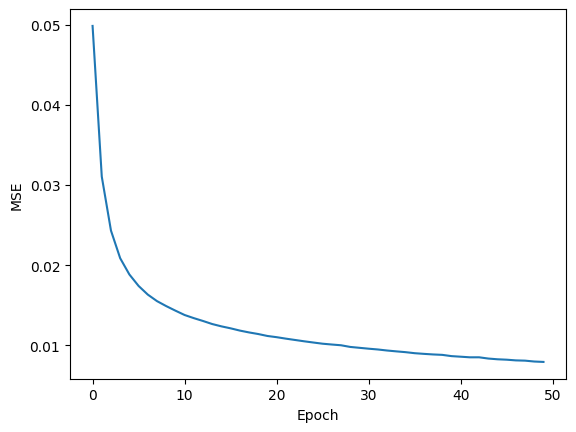

In [ ]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('MSE')
plt.xlabel('Epoch')

plt.show()

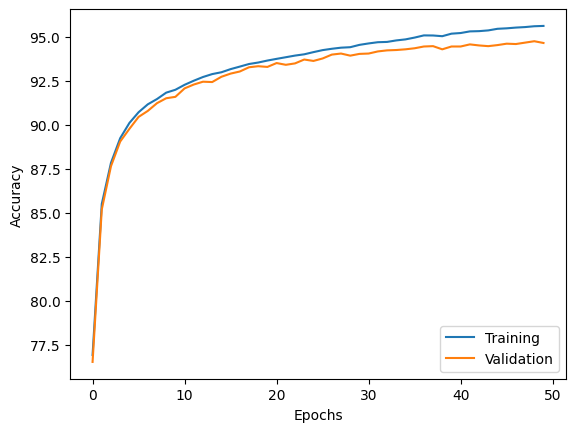

In [ ]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')

plt.show()